In [ ]:
# Author: Brent Artuch
# Date: 10-26-2025
# Couse: PHY-4730

# Qubit State Tomography

In [26]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler, Session
from qiskit.transpiler import generate_preset_pass_manager

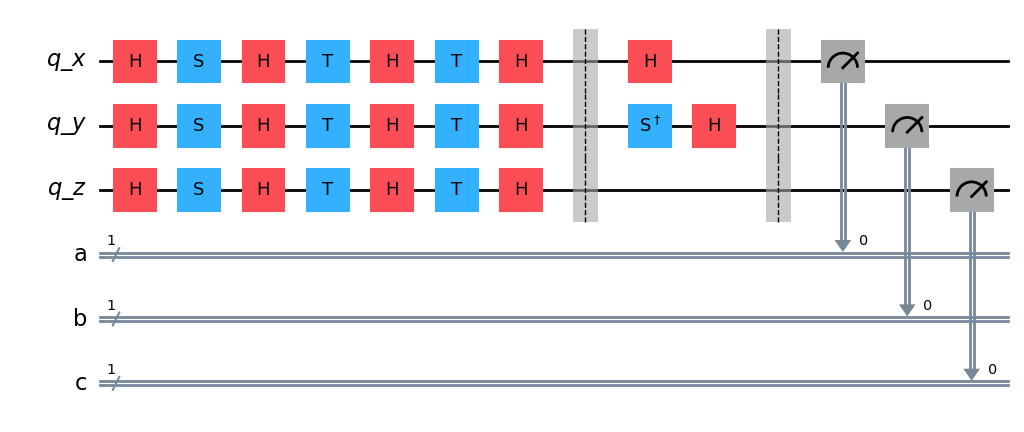

In [22]:
# Part 1: QST of Unentangled Qubit
q_x = QuantumRegister(1, "q_x")
q_y = QuantumRegister(1, "q_y")
q_z = QuantumRegister(1, "q_z")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")
c = ClassicalRegister(1, "c")

# Create the quantum circuit
qc = QuantumCircuit(q_x,q_y,q_z,a,b,c)

# Apply gate sequence to 0 state
qc.h([0,1,2])
qc.s([0,1,2])
qc.h([0,1,2])
qc.t([0,1,2])
qc.h([0,1,2])
qc.t([0,1,2])
qc.h([0,1,2])

qc.barrier()

# X-Basis transformation
qc.h(q_x)

# Y-Basis transformation
qc.sdg(q_y)
qc.h(q_y)

qc.barrier()

# Z-Basis
# Do Nothing

# Measure both qubits and store results in classical bits
qc.measure(q_x,a)
qc.measure(q_y,b)
qc.measure(q_z,c)

# Draw the circuit
display(qc.draw('mpl'))


Measurement results (counts): {'0 0 1': 28, '1 0 1': 75, '0 1 1': 79, '1 1 1': 255, '1 1 0': 1476, '1 0 0': 464, '0 1 0': 470, '0 0 0': 153}


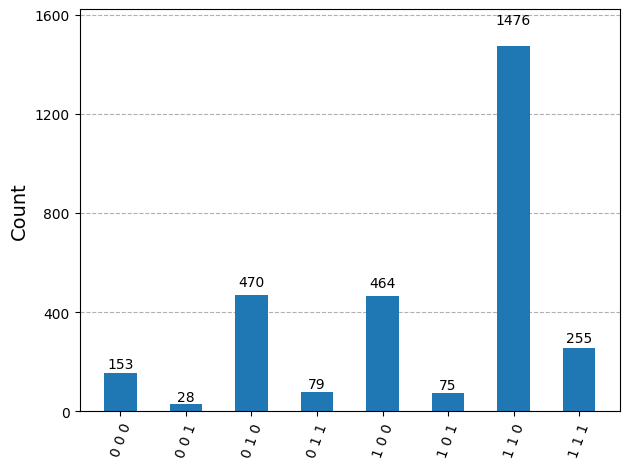

In [52]:
# Simulate the circuit
simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
job = simulator.run(compiled_circuit, shots=3000)
result = job.result()
counts = result.get_counts(compiled_circuit)

# 6. Print and visualize the results.
print("\nMeasurement results (counts):", counts)
plot_histogram(counts)

In [17]:
# Setup Quantum Backend (3 Qubits)
service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True, min_num_qubits=3)
print(f"Running on backend: {backend.name}")

Running on backend: ibm_kingston


In [27]:
# Transpile
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

# Run On Quantum Computer
with Session(backend=backend) as session:
    sampler = Sampler()
    job = sampler.run([isa_circuit], shots=3000)
    result = job.result()

AttributeError: 'PrimitiveResult' object has no attribute 'quasi_dists'

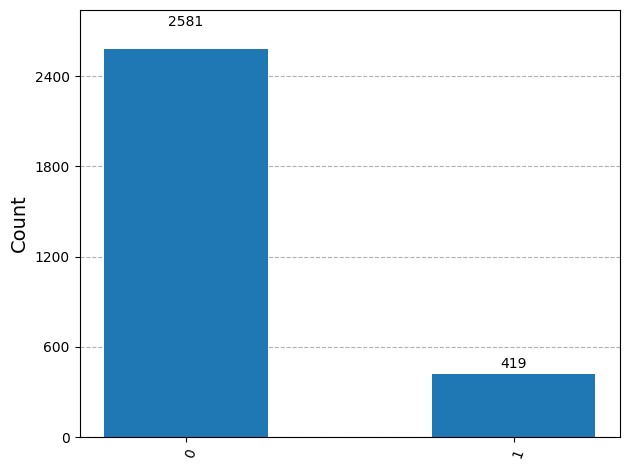

In [45]:
# X-Basis Results (a Classical Register)
counts = result[0].data.a.get_counts()
plot_histogram(counts)

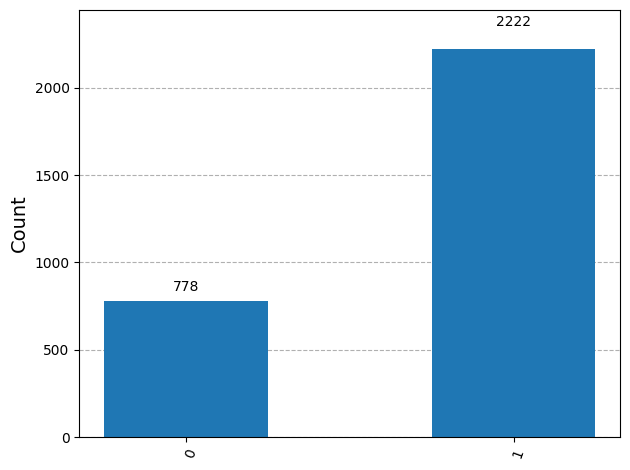

In [46]:
# Y-Basis Results (b Classical Register)
counts = result[0].data.b.get_counts()
plot_histogram(counts)

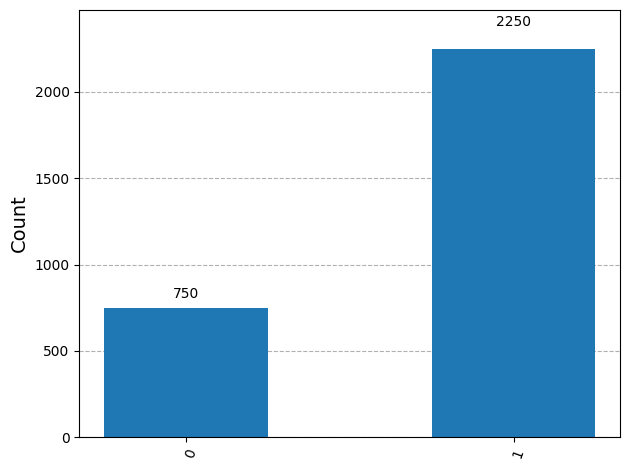

In [47]:
# Z-Basis Results (c Classical Register)
counts = result[0].data.c.get_counts()
plot_histogram(counts)

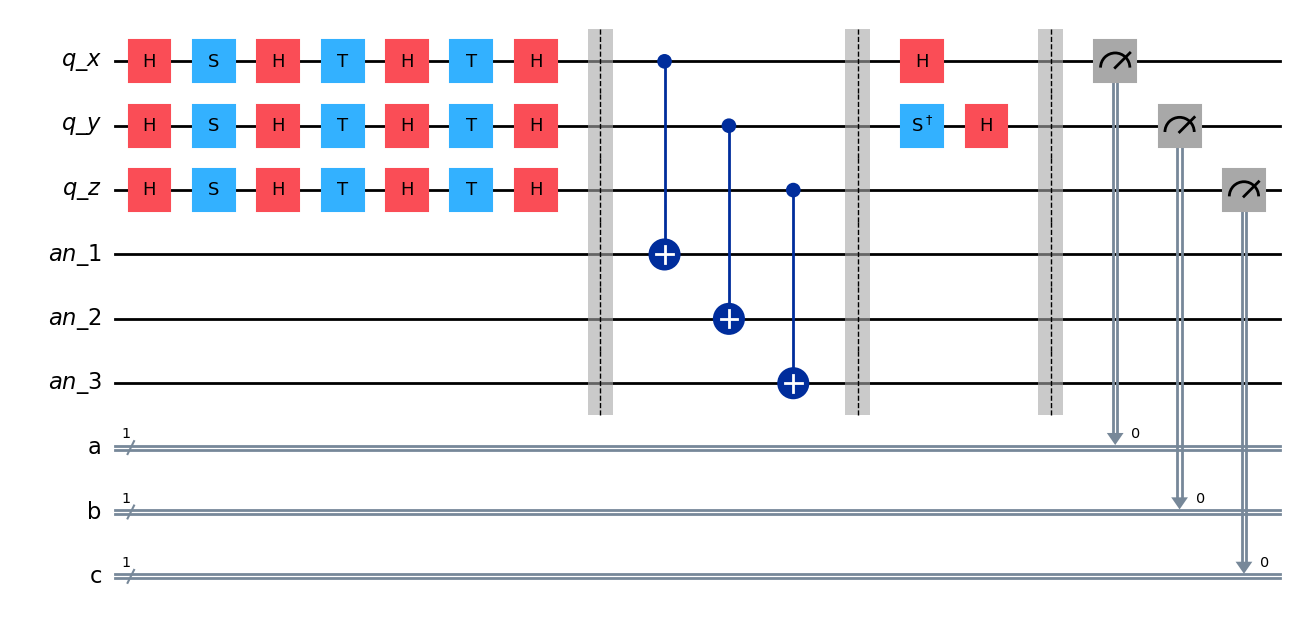

In [54]:
# Part 2: QST of Entangled Qubit
q_x = QuantumRegister(1, "q_x")
q_y = QuantumRegister(1, "q_y")
q_z = QuantumRegister(1, "q_z")
an_1 = QuantumRegister(1, "an_1")
an_2 = QuantumRegister(1, "an_2")
an_3 = QuantumRegister(1, "an_3")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")
c = ClassicalRegister(1, "c")

# Create the quantum circuit
qc = QuantumCircuit(q_x,q_y,q_z,an_1,an_2,an_3,a,b,c)

# Apply gate sequence to 0 state
qc.h([0,1,2])
qc.s([0,1,2])
qc.h([0,1,2])
qc.t([0,1,2])
qc.h([0,1,2])
qc.t([0,1,2])
qc.h([0,1,2])

qc.barrier()

# Apply CNOT operations for entaglement
qc.cx(q_x,an_1)
qc.cx(q_y,an_2)
qc.cx(q_z,an_3)

qc.barrier()

# X-Basis transformation
qc.h(q_x)

# Y-Basis transformation
qc.sdg(q_y)
qc.h(q_y)

qc.barrier()

# Z-Basis
# Do Nothing

# Measure both qubits and store results in classical bits
qc.measure(q_x,a)
qc.measure(q_y,b)
qc.measure(q_z,c)

# Draw the circuit
display(qc.draw('mpl'))


Measurement results (counts): {'1 1 0': 519, '0 1 0': 192, '0 0 0': 182, '1 0 0': 587, '0 0 1': 193, '1 1 1': 574, '0 1 1': 192, '1 0 1': 561}


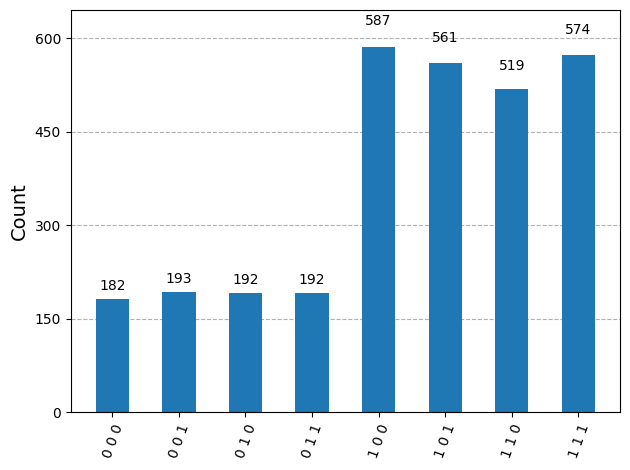

In [55]:
# Simulate the circuit
simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
job = simulator.run(compiled_circuit, shots=3000)
result = job.result()
counts = result.get_counts(compiled_circuit)

# 6. Print and visualize the results.
print("\nMeasurement results (counts):", counts)
plot_histogram(counts)

In [56]:
# Setup Quantum Backend (6 Qubits)
service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True, min_num_qubits=6)
print(f"Running on backend: {backend.name}")

Running on backend: ibm_kingston


In [57]:
# Transpile
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

# Run On Quantum Computer
with Session(backend=backend) as session:
    sampler = Sampler()
    job = sampler.run([isa_circuit], shots=1000)
    result = job.result()

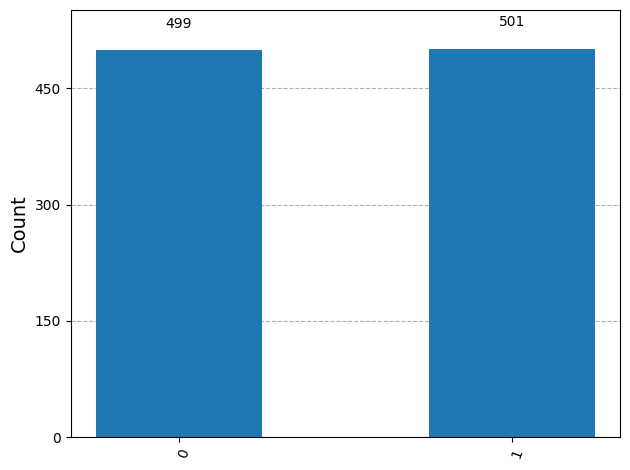

In [58]:
# X-Basis Results (a Classical Register)
counts = result[0].data.a.get_counts()
plot_histogram(counts)

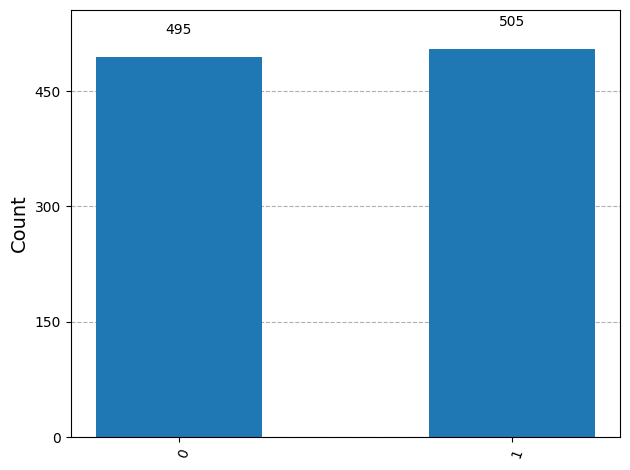

In [59]:
# Y-Basis Results (b Classical Register)
counts = result[0].data.b.get_counts()
plot_histogram(counts)

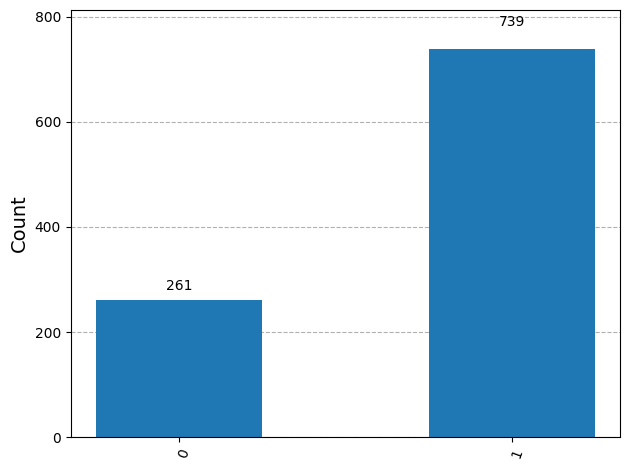

In [60]:
# Z-Basis Results (c Classical Register)
counts = result[0].data.c.get_counts()
plot_histogram(counts)

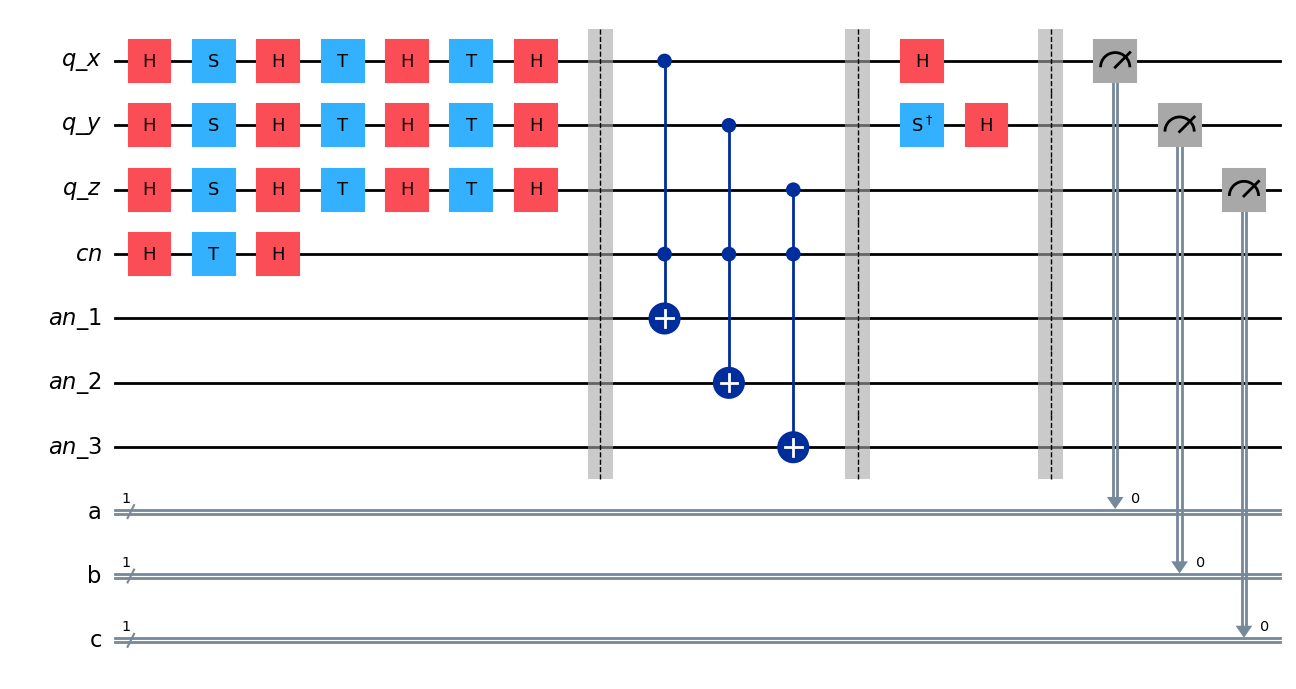

In [62]:
# Part 3: QST of Weak Entangled Qubit
q_x = QuantumRegister(1, "q_x")
q_y = QuantumRegister(1, "q_y")
q_z = QuantumRegister(1, "q_z")
cn = QuantumRegister(1, "cn")
an_1 = QuantumRegister(1, "an_1")
an_2 = QuantumRegister(1, "an_2")
an_3 = QuantumRegister(1, "an_3")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")
c = ClassicalRegister(1, "c")

# Create the quantum circuit
qc = QuantumCircuit(q_x,q_y,q_z,cn,an_1,an_2,an_3,a,b,c)

# Apply gate sequence to 0 state
qc.h([0,1,2])
qc.s([0,1,2])
qc.h([0,1,2])
qc.t([0,1,2])
qc.h([0,1,2])
qc.t([0,1,2])
qc.h([0,1,2])

# Apply HTH to 'entangle control' qubit
qc.h(cn)
qc.t(cn)
qc.h(cn)

qc.barrier()

# Apply CCX for weak entanglement
qc.ccx(q_x,cn,an_1)
qc.ccx(q_y,cn,an_2)
qc.ccx(q_z,cn,an_3)

qc.barrier()

# X-Basis transformation
qc.h(q_x)

# Y-Basis transformation
qc.sdg(q_y)
qc.h(q_y)

qc.barrier()

# Z-Basis
# Do Nothing

# Measure both qubits and store results in classical bits
qc.measure(q_x,a)
qc.measure(q_y,b)
qc.measure(q_z,c)

# Draw the circuit
display(qc.draw('mpl'))


Measurement results (counts): {'0 0 1': 42, '1 0 1': 144, '1 0 0': 495, '0 1 0': 456, '0 0 0': 163, '1 1 1': 291, '0 1 1': 101, '1 1 0': 1308}


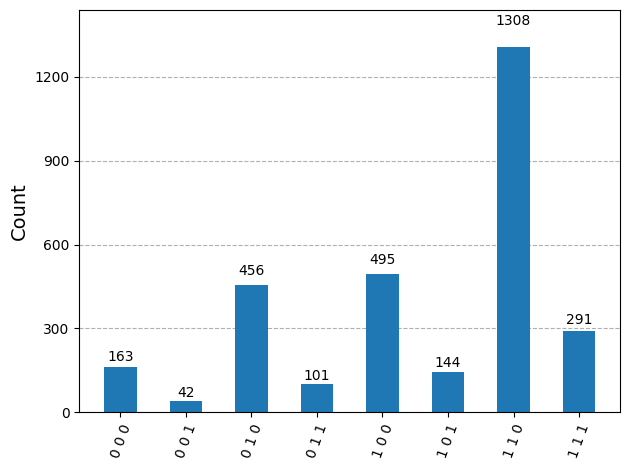

In [66]:
# Simulate the circuit
simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
job = simulator.run(compiled_circuit, shots=3000)
result = job.result()
counts = result.get_counts(compiled_circuit)

# 6. Print and visualize the results.
print("\nMeasurement results (counts):", counts)
plot_histogram(counts)

In [67]:
# Setup Quantum Backend (6 Qubits)
service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True, min_num_qubits=7)
print(f"Running on backend: {backend.name}")

Running on backend: ibm_kingston


In [68]:
# Transpile
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

# Run On Quantum Computer
with Session(backend=backend) as session:
    sampler = Sampler()
    job = sampler.run([isa_circuit], shots=1000)
    result = job.result()

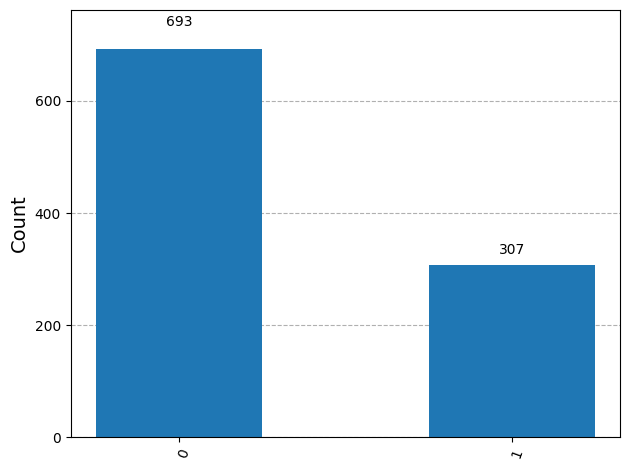

In [69]:
# X-Basis Results (a Classical Register)
counts = result[0].data.a.get_counts()
plot_histogram(counts)

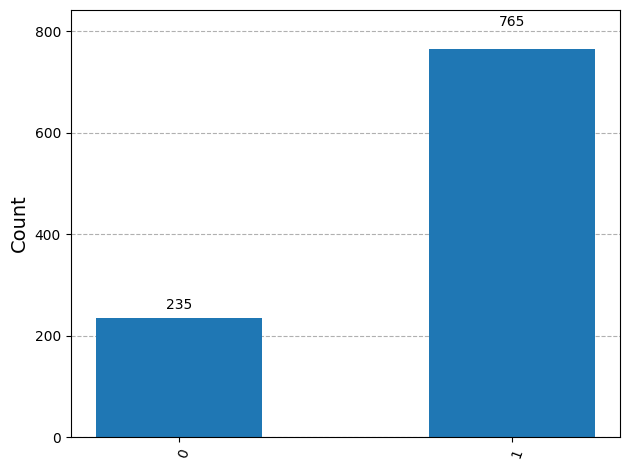

In [70]:
# Y-Basis Results (b Classical Register)
counts = result[0].data.b.get_counts()
plot_histogram(counts)

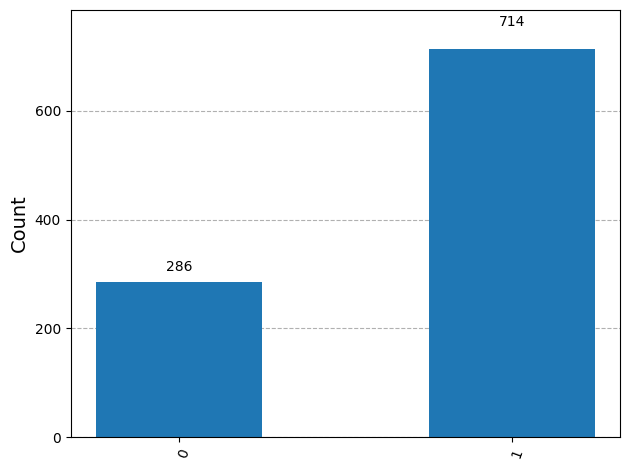

In [71]:
# Z-Basis Results (c Classical Register)
counts = result[0].data.c.get_counts()
plot_histogram(counts)